In [31]:
import pandas as pd
import numpy as np

df_vendas = pd.read_csv("vendas_tech.csv", low_memory=False)
df_gerentes =  pd.read_excel("gerentes_lojas.xlsx") 

display(df_gerentes)
display(df_vendas)

,Loja,Gerente,Meta_Mensal
0,São Paulo,Carlos,50000
1,Rio de Janeiro,Fernanda,60000
2,Curitiba,Roberto,45000
3,Belo Horizonte,Juliana,55000
4,Recife,Marcos,48000
5,Porto Alegre,Pedro,42000
6,Salvador,Ana,52000


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


In [ ]:
#inspeçao
display(df_vendas.info())
display(df_vendas.describe())

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
53259,53260,2024-08-18,Porto Alegre,"Monitor 27""",1200.0,1,Cliente_15547,NaN
20058,20059,2024-02-08,Salvador,Teclado Mecânico,250.0,1,Cliente_5294,NaN
72253,72254,2023-01-05,Salvador,iPhone 14,5500.0,1,Cliente_9554,NaN
39741,39742,2023-07-12,Porto Alegre,Mouse Gamer,120.0,1,Cliente_2151,NaN
49180,49181,2023-04-29,Curitiba,Mouse Gamer,120.0,1,Cliente_17007,NaN
96981,96982,2023-04-16,Rio de Janeiro,Notebook HP,3200.0,1,Cliente_21276,NaN
55108,55109,2024-04-21,Salvador,Notebook Dell,3500.0,2,Cliente_3690,NaN
20277,20278,2024-09-26,Belo Horizonte,Mouse Gamer,120.0,1,Cliente_19895,NaN
18483,18484,2023-09-03,Recife,Teclado Mecânico,250.0,1,Cliente_27929,NaN
58950,58951,2024-08-20,Recife,Smartphone Samsung,2200.0,1,Cliente_2529,NaN


,ID_Pedido,Preco_Unitario,Qtd
count,100100.000000,100100.000000,100100.000000
mean,50004.810180,2000.204595,1.499101
std,28866.872543,1841.050733,1.241605
min,1.000000,40.000000,1.000000
25%,25008.750000,120.000000,1.000000
50%,50004.500000,1200.000000,1.000000
75%,75002.250000,3200.000000,1.000000
max,100000.000000,5500.000000,10.000000


In [ ]:
#tratamento de dados
#display(df_vendas["Loja"])
#display(df_vendas[["Loja", "Cliente"]])
df_selecionado = df_vendas[["Produto", "Preco_Unitario", "Qtd"]]
#display(df_selecionado)

#colunas
df_analise = df_vendas.drop(columns=["Data_Base"]) #sem alterar a original

#nulos
#df_analise.dropna() #exclui linhas que tem valor vazio na base de dados
df_analise["Loja"] = df_analise["Loja"].fillna("Online")

#tipos de dados errados, ex: data tipo string
df_analise["Data"] = pd.to_datetime(df_analise["Data"], format='%Y-%m-%d')

#padronizacao de strings
df_analise["Loja"] = df_analise["Loja"].str.strip() #tirar espaços indesejados
df_analise["Loja"] = df_analise["Loja"].str.title() #formataçao igual em todas as cidades
df_gerentes["Loja"] = df_gerentes["Loja"].str.strip()
df_gerentes["Loja"] = df_gerentes["Loja"].str.title()

#remocao de duplicatas
df_analise = df_analise.drop_duplicates(subset=["ID_Pedido"], keep="first")
#ve se tem id de pedidos duplicados, se tiver mantem o primeiro

display(df_analise)
display(df_analise.info())

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[us]
 2   Loja            100000 non-null  str           
 3   Produto         100000 non-null  str           
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 5.3 MB


None

In [34]:
#criaçao e tratamento de novas colunas IMPORTANTE

#faturamento
df_analise["Faturamento"] = df_analise["Preco_Unitario"] * df_analise["Qtd"]

# forma de venda
df_analise["Forma_de_venda"] = np.where(df_analise["Loja"] == "Online", "Online", "Presencial")
#se loja for == "online" escreve online se for != escreve presencial

#Regiao
display(df_analise["Loja"].unique())
def definir_regiao(loja):
    dicionario_regioes = {
        'São Paulo' : "Sudeste",
        'Belo Horizonte' : "Sudeste",
        'Online' : "Online",
        'Rio De Janeiro' : "Sudeste",
        'Salvador' : "Nordeste",
        'Recife' : "Nordeste",
        'Curitiba' : "Sul",
        'Porto Alegre' : "Sul"
    }
    return dicionario_regioes[loja]

df_analise["Regiao"] = df_analise["Loja"].map(definir_regiao)
display(df_analise)

<StringArray>
[     'São Paulo', 'Belo Horizonte',         'Online', 'Rio De Janeiro',
       'Salvador',         'Recife',       'Curitiba',   'Porto Alegre']
Length: 8, dtype: str

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_venda,Regiao
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Presencial,Sudeste
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Presencial,Sudeste
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Presencial,Sudeste
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0,Presencial,Sudeste
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Presencial,Sul
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0,Presencial,Sul


In [35]:
#analisar -> filtrar
df_analise = df_analise.sort_values(by=["Data", "Faturamento"], ascending=False)
df_analise = df_analise.reset_index(drop=True)

# exportar pedaços da base
#condicional
#df_id_pedido = df_analise[df_analise["ID_Pedido"]==4]
#criar uma nova tabela com base em uma condiçao de dado de uma tabela ja existente

df_vendas_sp = df_analise[df_analise["Loja"] == "São Paulo"]

display(df_analise)
df_vendas_sp.to_csv("Vendas_SP.csv", index=False)
display(df_vendas_sp)

#exportar vendas de 2024
df_vendas_2024 = df_analise[df_analise["Data"].dt.year == 2024]
display(df_vendas_2024 )

#vendas de cabo hdmi do sul
df_vendas_HDMI_sul = df_analise[(df_analise["Produto"] == "Cabo HDMI") & (df_analise["Regiao"] ==  "Sul")]
display(df_vendas_HDMI_sul)


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_venda,Regiao
0,35192,2024-12-30,Salvador,iPhone 14,5500.0,2,Cliente_7615,11000.0,Presencial,Nordeste
1,60794,2024-12-30,Rio De Janeiro,Smartphone Samsung,2200.0,5,Cliente_9964,11000.0,Presencial,Sudeste
2,86379,2024-12-30,Salvador,iPhone 14,5500.0,2,Cliente_25166,11000.0,Presencial,Nordeste
3,40137,2024-12-30,Recife,Notebook Dell,3500.0,2,Cliente_11509,7000.0,Presencial,Nordeste
4,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,88109,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_22054,40.0,Presencial,Nordeste
99996,91765,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_1746,40.0,Presencial,Nordeste
99997,93303,2023-01-01,Belo Horizonte,Cabo HDMI,40.0,1,Cliente_11142,40.0,Presencial,Sudeste
99998,95393,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_23137,40.0,Presencial,Nordeste


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_venda,Regiao
6,177,2024-12-30,São Paulo,Smartphone Samsung,2200.0,3,Cliente_4388,6600.0,Presencial,Sudeste
8,7446,2024-12-30,São Paulo,iPhone 14,5500.0,1,Cliente_1302,5500.0,Presencial,Sudeste
15,60640,2024-12-30,São Paulo,iPhone 14,5500.0,1,Cliente_13172,5500.0,Presencial,Sudeste
20,77621,2024-12-30,São Paulo,iPhone 14,5500.0,1,Cliente_19106,5500.0,Presencial,Sudeste
21,91693,2024-12-30,São Paulo,iPhone 14,5500.0,1,Cliente_17362,5500.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99960,53171,2023-01-01,São Paulo,Teclado Mecânico,250.0,1,Cliente_19747,250.0,Presencial,Sudeste
99962,59136,2023-01-01,São Paulo,Teclado Mecânico,250.0,1,Cliente_14239,250.0,Presencial,Sudeste
99978,39483,2023-01-01,São Paulo,Mouse Gamer,120.0,1,Cliente_1274,120.0,Presencial,Sudeste
99979,48375,2023-01-01,São Paulo,Mouse Gamer,120.0,1,Cliente_1544,120.0,Presencial,Sudeste


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_venda,Regiao
0,35192,2024-12-30,Salvador,iPhone 14,5500.0,2,Cliente_7615,11000.0,Presencial,Nordeste
1,60794,2024-12-30,Rio De Janeiro,Smartphone Samsung,2200.0,5,Cliente_9964,11000.0,Presencial,Sudeste
2,86379,2024-12-30,Salvador,iPhone 14,5500.0,2,Cliente_25166,11000.0,Presencial,Nordeste
3,40137,2024-12-30,Recife,Notebook Dell,3500.0,2,Cliente_11509,7000.0,Presencial,Nordeste
4,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
49572,80685,2024-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_27122,40.0,Presencial,Nordeste
49573,83656,2024-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_15422,40.0,Presencial,Nordeste
49574,85554,2024-01-01,Belo Horizonte,Cabo HDMI,40.0,1,Cliente_29280,40.0,Presencial,Sudeste
49575,88442,2024-01-01,Recife,Cabo HDMI,40.0,1,Cliente_2801,40.0,Presencial,Nordeste


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_venda,Regiao
117,35127,2024-12-30,Curitiba,Cabo HDMI,40.0,2,Cliente_20687,80.0,Presencial,Sul
118,47774,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_14363,80.0,Presencial,Sul
119,64473,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_11598,80.0,Presencial,Sul
125,75695,2024-12-30,Porto Alegre,Cabo HDMI,40.0,1,Cliente_29587,40.0,Presencial,Sul
126,78584,2024-12-30,Curitiba,Cabo HDMI,40.0,1,Cliente_21307,40.0,Presencial,Sul
...,...,...,...,...,...,...,...,...,...,...
99987,35599,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_18680,40.0,Presencial,Sul
99988,37130,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_22886,40.0,Presencial,Sul
99989,49140,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_24445,40.0,Presencial,Sul
99994,70138,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_9348,40.0,Presencial,Sul


In [ ]:
#analise de agrupamento
display(df_analise)

#quero saber qual loja vendeu mais
analise_vendasPorLoja = df_analise[["Loja","Faturamento"]].groupby("Loja").sum()
analise_vendasPorLoja = analise_vendasPorLoja.sort_values(by="Faturamento", ascending=False)
analise_vendasPorLoja = analise_vendasPorLoja.reset_index()
display(analise_vendasPorLoja)

#ranking de produts que mais venderam no online e o quanto eles venderam
df_vendas_online = df_analise[df_analise["Loja"] == "Online"]
analise_produtos_online = df_vendas_online[["Produto", "Qtd"]].groupby("Produto").sum()
analise_produtos_online = analise_produtos_online.sort_values(by="Qtd", ascending=False)
analise_produtos_online = analise_produtos_online.rename(columns={"Qtd" : "Vendas Totais"})
display(analise_produtos_online)

#ranking de quais produtos que venderam mais em cada loja
#quais prod venderam mais em cada uma das lojas
analise_produtos_em_lojas = df_analise[["Loja", "Produto", "Qtd"]].groupby(["Loja", "Produto"]).sum()

#anlise de lojas que mais venderam x prod
analise_lojas_em_produtos = df_analise[["Loja", "Produto", "Qtd"]].groupby(["Produto", "Loja"]).sum()

with pd.option_context("display.max_rows", None):
    display(analise_produtos_em_lojas)
    display(analise_lojas_em_produtos)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_venda,Regiao
0,35192,2024-12-30,Salvador,iPhone 14,5500.0,2,Cliente_7615,11000.0,Presencial,Nordeste
1,60794,2024-12-30,Rio De Janeiro,Smartphone Samsung,2200.0,5,Cliente_9964,11000.0,Presencial,Sudeste
2,86379,2024-12-30,Salvador,iPhone 14,5500.0,2,Cliente_25166,11000.0,Presencial,Nordeste
3,40137,2024-12-30,Recife,Notebook Dell,3500.0,2,Cliente_11509,7000.0,Presencial,Nordeste
4,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,88109,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_22054,40.0,Presencial,Nordeste
99996,91765,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_1746,40.0,Presencial,Nordeste
99997,93303,2023-01-01,Belo Horizonte,Cabo HDMI,40.0,1,Cliente_11142,40.0,Presencial,Sudeste
99998,95393,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_23137,40.0,Presencial,Nordeste


,Loja,Faturamento
0,Salvador,42300610.0
1,Rio De Janeiro,42294720.0
2,Recife,42190390.0
3,São Paulo,42090690.0
4,Belo Horizonte,41714890.0
5,Porto Alegre,41678460.0
6,Curitiba,41121720.0
7,Online,6080850.0


,Vendas Totais
Produto,
Notebook HP,442
Cabo HDMI,403
iPhone 14,390
Mouse Gamer,379
Notebook Dell,369
Teclado Mecânico,343
"Monitor 27""",332
Smartphone Samsung,311


Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
               Smartphone Samsung  2597
               Teclado Mecânico    2609
               iPhone 14           2478
Curitiba       Cabo HDMI           2698
               Monitor 27"         2626
               Mouse Gamer         2600
               Notebook Dell       2517
               Notebook HP         2529
               Smartphone Samsung  2444
               Teclado Mecânico    2742
               iPhone 14           2652
Online         Cabo HDMI            403
               Monitor 27"          332
               Mouse Gamer          379
               Notebook Dell        369
               Notebook HP          442
               Smartphone Samsung   311
               Teclado Mecânico     343
               iPhone 14            390
Porto Alegre   Cabo HDMI           2571
               Monitor 27"         2655
               Mouse Gamer         2611
               Notebook Dell       2770
               Notebook HP         2511
               Smartphone Samsung  2603
               Teclado Mecânico    2598
               iPhone 14           2540
Recife         Cabo HDMI           2534
               Monitor 27"         2647
               Mouse Gamer         2639
               Notebook Dell       2566
               Notebook HP         2651
               Smartphone Samsung  2660
               Teclado Mecânico    2775
               iPhone 14           2652
Rio De Janeiro Cabo HDMI           2747
               Monitor 27"         2798
               Mouse Gamer         2652
               Notebook Dell       2534
               Notebook HP         2614
               Smartphone Samsung  2626
               Teclado Mecânico    2548
               iPhone 14           2702
Salvador       Cabo HDMI           2566
               Monitor 27"         2545
               Mouse Gamer         2711
               Notebook Dell       2512
               Notebook HP         2785
               Smartphone Samsung  2627
               Teclado Mecânico    2579
               iPhone 14           2671
São Paulo      Cabo HDMI           2649
               Monitor 27"         2796
               Mouse Gamer         2714
               Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

Qtd
Produto            Loja                
Cabo HDMI          Belo Horizonte  2636
                   Curitiba        2698
                   Online           403
                   Porto Alegre    2571
                   Recife          2534
                   Rio De Janeiro  2747
                   Salvador        2566
                   São Paulo       2649
Monitor 27"        Belo Horizonte  2625
                   Curitiba        2626
                   Online           332
                   Porto Alegre    2655
                   Recife          2647
                   Rio De Janeiro  2798
                   Salvador        2545
                   São Paulo       2796
Mouse Gamer        Belo Horizonte  2465
                   Curitiba        2600
                   Online           379
                   Porto Alegre    2611
                   Recife          2639
                   Rio De Janeiro  2652
                   Salvador        2711
                   São Paulo       2714
Notebook Dell      Belo Horizonte  2654
                   Curitiba        2517
                   Online           369
                   Porto Alegre    2770
                   Recife          2566
                   Rio De Janeiro  2534
                   Salvador        2512
                   São Paulo       2535
Notebook HP        Belo Horizonte  2775
                   Curitiba        2529
                   Online           442
                   Porto Alegre    2511
                   Recife          2651
                   Rio De Janeiro  2614
                   Salvador        2785
                   São Paulo       2592
Smartphone Samsung Belo Horizonte  2597
                   Curitiba        2444
                   Online           311
                   Porto Alegre    2603
                   Recife          2660
                   Rio De Janeiro  2626
                   Salvador        2627
                   São Paulo       2476
Teclado Mecânico   Belo Horizonte  2609
                   Curitiba        2742
                   Online           343
                   Porto Alegre    2598
                   Recife          2775
                   Rio De Janeiro  2548
                   Salvador        2579
                   São Paulo       2589
iPhone 14          Belo Horizonte  2478
                   Curitiba        2652
                   Online           390
                   Porto Alegre    2540
                   Recife          2652
                   Rio De Janeiro  2702
                   Salvador        2671
                   São Paulo       2735

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_venda,Regiao,Mes-Ano
95766,17952,2023-01-31,Rio De Janeiro,iPhone 14,5500.0,10,Cliente_8445,55000.0,Presencial,Sudeste,2023-01
95767,46662,2023-01-31,Online,iPhone 14,5500.0,10,Cliente_3691,55000.0,Online,Online,2023-01
95768,5218,2023-01-31,São Paulo,Notebook Dell,3500.0,10,Cliente_26218,35000.0,Presencial,Sudeste,2023-01
95769,24976,2023-01-31,Recife,Notebook HP,3200.0,10,Cliente_6013,32000.0,Presencial,Nordeste,2023-01
95770,70888,2023-01-31,Porto Alegre,iPhone 14,5500.0,5,Cliente_4657,27500.0,Presencial,Sul,2023-01
...,...,...,...,...,...,...,...,...,...,...,...
99995,88109,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_22054,40.0,Presencial,Nordeste,2023-01
99996,91765,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_1746,40.0,Presencial,Nordeste,2023-01
99997,93303,2023-01-01,Belo Horizonte,Cabo HDMI,40.0,1,Cliente_11142,40.0,Presencial,Sudeste,2023-01
99998,95393,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_23137,40.0,Presencial,Nordeste,2023-01


,Faturamento
Mes-Ano,
2023-01,12930290.0
2023-02,11515150.0
2023-03,12516080.0
2023-04,12528900.0
2023-05,12940470.0
2023-06,12455820.0
2023-07,12550990.0
2023-08,12989130.0
2023-09,12118180.0


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_venda,Regiao,Mes-Ano
0,35192,2024-12-30,Salvador,iPhone 14,5500.0,2,Cliente_7615,11000.0,Presencial,Nordeste,2024-12
1,60794,2024-12-30,Rio De Janeiro,Smartphone Samsung,2200.0,5,Cliente_9964,11000.0,Presencial,Sudeste,2024-12
2,86379,2024-12-30,Salvador,iPhone 14,5500.0,2,Cliente_25166,11000.0,Presencial,Nordeste,2024-12
3,40137,2024-12-30,Recife,Notebook Dell,3500.0,2,Cliente_11509,7000.0,Presencial,Nordeste,2024-12
4,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste,2024-12
...,...,...,...,...,...,...,...,...,...,...,...
99995,88109,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_22054,40.0,Presencial,Nordeste,2023-01
99996,91765,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_1746,40.0,Presencial,Nordeste,2023-01
99997,93303,2023-01-01,Belo Horizonte,Cabo HDMI,40.0,1,Cliente_11142,40.0,Presencial,Sudeste,2023-01
99998,95393,2023-01-01,Salvador,Cabo HDMI,40.0,1,Cliente_23137,40.0,Presencial,Nordeste,2023-01


,Loja,Faturamento,Gerente,Meta_Mensal,Bateu Meta
0,Belo Horizonte,1779100.0,Juliana,55000.0,0
1,Curitiba,1986920.0,Roberto,45000.0,1
2,Online,404570.0,NaN,NaN,0
3,Porto Alegre,1726640.0,Pedro,42000.0,1
4,Recife,1779020.0,Marcos,48000.0,1
5,Rio De Janeiro,1736830.0,Fernanda,60000.0,0
6,Salvador,1686070.0,Ana,52000.0,0
7,São Paulo,1831140.0,Carlos,50000.0,1


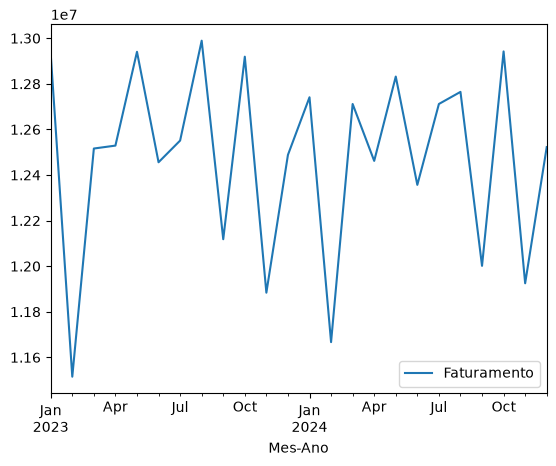

In [38]:
#analise quem bateu a meta
df_meta = df_analise[(df_analise["Data"].dt.year == 2023) & (df_analise["Data"].dt.month == 1)]
display(df_meta)

df_meta = df_meta[["Loja", "Faturamento"]].groupby("Loja", as_index=False).sum()
df_meta = df_meta.merge(df_gerentes, on="Loja", how="left")
meses = 36
df_meta["Bateu Meta"] = np.where(df_meta["Faturamento"] >= df_meta["Meta_Mensal"] * meses, "1", "0")

df_analise["Mes-Ano"] = df_analise["Data"].dt.to_period("M")
df_vendas_mes = df_analise[["Mes-Ano", "Faturamento"]].groupby("Mes-Ano").sum()
df_vendas_mes = df_vendas_mes.sort_values(by="Mes-Ano")
display(df_vendas_mes)
df_vendas_mes.plot()

display(df_analise)
display(df_meta)